In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc= pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean.csv")
df_svc_pc=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean_pc.csv")
df_svc_pn=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean_pn.csv")
df_svc_sla=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean_sla.csv")
df_svc_d13c=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean_d13c.csv")
# df_svc_la= pd.read_csv(r"D:\wenqu\2024_data\SVC\update2\T-squared\spectral_trait_mean.csv")
df_svc_d15n=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean_d15n.csv")
df_svc_ldmc=  pd.read_csv(r"D:\wenqu\2024_data\SVC\update4\spectral_trait_mean_ldmc.csv")
# df_svc_la

In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    # b_std = 'b' + str(i) + '_std'
    # b_name.append(b_std)


b_name = np.array(b_name)
# b_name

In [4]:
x_d13c = np.array(df_svc_d13c[b_name])
x_d15n = np.array(df_svc_d15n[b_name])
x_ldmc = np.array(df_svc_ldmc[b_name])
x_pc = np.array(df_svc_pc[b_name])
x_pn = np.array(df_svc_pn[b_name])
x_sla = np.array(df_svc_sla[b_name])
# x_la = np.array(df_svc_la[b_name])

In [5]:
df_svc_d13c

,site,CWM_Ld13C,CWM_Ld15N,CWM_log10_LA,CWM_log10_SLA,CWM_log10_PN,CWM_log10_LDMC,CWM_log10_PC,b1,b2,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S3C_Q02,-28.493357,-1.008321,0.328341,0.982212,1.192394,2.679461,2.662491,0.011361,0.011405,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
1,S3C_Q03,-29.244686,-4.591383,-0.106780,0.447457,0.984538,2.810259,2.657785,0.023802,0.024319,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
2,S3C_Q04,-28.446174,-1.313879,0.153008,0.667112,1.125512,2.714658,2.641835,0.028783,0.029309,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
3,S3C_Q05,-28.453987,-2.819253,-0.107205,0.509009,1.106397,2.474649,2.648293,0.022247,0.023094,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
4,S3C_Q07,-28.669745,-2.069676,0.351740,0.673271,1.107105,2.701362,2.641516,0.021825,0.022113,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,S1B_Q32,-27.741047,-0.975923,0.828249,1.025977,1.324210,2.607794,2.686539,0.008917,0.007457,...,0.071273,0.068599,0.061035,0.061785,0.066831,0.071272,0.061311,0.067115,0.077332,0.086806
118,S2C_Q01,-27.997066,2.215618,0.927549,0.791126,1.188391,2.729070,2.664670,0.023235,0.020013,...,0.064067,0.065335,0.056351,0.058132,0.060137,0.053068,0.056950,0.056443,0.056510,0.060923
119,S2C_Q02,-26.680322,3.394480,1.132447,0.792150,1.157011,2.819904,2.664165,0.018854,0.021207,...,0.059653,0.061913,0.054972,0.055386,0.058106,0.053975,0.056810,0.056029,0.052853,0.065612
120,S2C_Q03,-27.625914,2.497644,0.711165,0.815534,1.199038,2.713769,2.674433,0.019624,0.011369,...,0.071652,0.064486,0.066432,0.066675,0.063462,0.064587,0.068054,0.064561,0.068769,0.071439


In [6]:
# labels_la = [] 
# for i in range(len(df_svc_la['site'])):    
#     site_name = df_svc_la['site'][i].split("_")[0]
#     labels_la.append(site_name)


labels_d13c = [] 
for i in range(len(df_svc_d13c['site'])):    
    site_name = df_svc_d13c['site'][i].split("_")[0]
    labels_d13c.append(site_name)


labels_d15n = [] 
for i in range(len(df_svc_d15n['site'])):    
    site_name = df_svc_d15n['site'][i].split("_")[0]
    labels_d15n.append(site_name)


labels_ldmc = [] 
for i in range(len(df_svc_ldmc['site'])):    
    site_name = df_svc_ldmc['site'][i].split("_")[0]
    labels_ldmc.append(site_name)

In [7]:
labels_pc = [] 
for i in range(len(df_svc_pc['site'])):    
    site_name = df_svc_pc['site'][i].split("_")[0]
    labels_pc.append(site_name)
# labels_pc

labels_pn = [] 
for i in range(len(df_svc_pn['site'])):    
    site_name = df_svc_pn['site'][i].split("_")[0]
    labels_pn.append(site_name)


labels_sla = [] 
for i in range(len(df_svc_sla['site'])):    
    site_name = df_svc_sla['site'][i].split("_")[0]
    labels_sla.append(site_name)

In [8]:
y_d13c = df_svc_d13c['CWM_Ld13C'].to_numpy()
y_d15n = df_svc_d15n['CWM_Ld15N'].to_numpy()
y_ldmc = df_svc_ldmc['CWM_log10_LDMC'].to_numpy()
y_pc = df_svc_pc['CWM_log10_PC'].to_numpy()
y_pn = df_svc_pn['CWM_log10_PN'].to_numpy()
y_sla = df_svc_sla['CWM_log10_SLA'].to_numpy()
# y_la = df_svc_la['CWM_log10_LA'].to_numpy()

In [9]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [10]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## pc

In [ ]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_pc, y_pc, 20)

In [12]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\pc.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_pc,                         
                             ncomp, labels_pc, file_name_sla)

NameError: name 'opt_Xc' is not defined

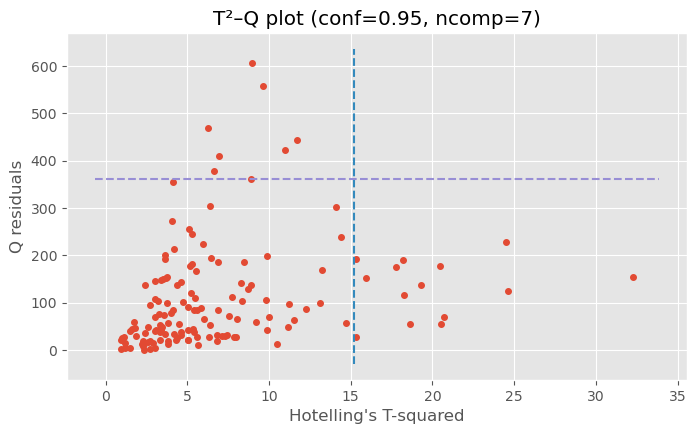

Orthogonal outliers indices: [  0   9  29  68  75  83  87 122]
Bad leverage indices: []
Good leverage indices (usually NOT removed): [ 10  22  36  51  89 106 107 108 109 117 118 120 121 128]

Final outlier indices (to consider removing): [  0   9  29  68  75  83  87 122]
Number of outliers: 8


In [13]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import f
import matplotlib.pyplot as plt

conf = 0.95
ncomp = 7
X2 = x_pc
Y = y_pc

# ===== PLS =====
pls = PLSRegression(n_components=ncomp)  # sklearn 默认 scale=True（会标准化）
pls.fit(X2, Y)

# ===== scores / loadings =====
T = pls.x_scores_
P = pls.x_loadings_

# ===== Q residuals =====
Err = X2 - np.dot(T, P.T)
Q = np.sum(Err**2, axis=1)

# ===== Hotelling's T^2 =====
T_std = np.std(T, axis=0, ddof=1)
T_std[T_std == 0] = 1e-12   # 防止除零（极少发生）
Tsq = np.sum((T / T_std)**2, axis=1)

# ===== T^2 threshold (F distribution) =====

Tsq_conf = (
    f.ppf(q=conf, dfn=ncomp, dfd=(X2.shape[0] - ncomp))
    * ncomp * (X2.shape[0] - 1) / (X2.shape[0] - ncomp)
)

# ===== Q threshold (empirical quantile) =====
Q_conf = np.quantile(Q, conf)

# ===== Plot =====
with plt.style.context("ggplot"):
    plt.figure(figsize=(8, 4.5))
    plt.plot(Tsq, Q, "o", markersize=4)

    ymin, ymax = plt.ylim()
    xmin, xmax = plt.xlim()

    plt.plot([Tsq_conf, Tsq_conf], [ymin, ymax], "--")
    plt.plot([xmin, xmax], [Q_conf, Q_conf], "--")

    plt.xlabel("Hotelling's T-squared")
    plt.ylabel("Q residuals")
    plt.title(f"T²–Q plot (conf={conf}, ncomp={ncomp})")

plt.show()
# ===== (可选) 输出异常点索引 =====

# ===== 正确分类 =====
regular = (Tsq <= Tsq_conf) & (Q <= Q_conf)
good_leverage = (Tsq > Tsq_conf) & (Q <= Q_conf)
orthogonal_outlier = (Tsq <= Tsq_conf) & (Q > Q_conf)
bad_leverage = (Tsq > Tsq_conf) & (Q > Q_conf)

# 只把 orthogonal + bad leverage 当 outliers
out_idx = np.where(orthogonal_outlier | bad_leverage)[0]

print("Orthogonal outliers indices:", np.where(orthogonal_outlier)[0])
print("Bad leverage indices:", np.where(bad_leverage)[0])
print("Good leverage indices (usually NOT removed):", np.where(good_leverage)[0])

print("\nFinal outlier indices (to consider removing):", out_idx)
print("Number of outliers:", len(out_idx))


In [15]:
df_svc_pc['site'][87]

'S7_Q27'

In [14]:
# ===== 定义 orthogonal outliers =====
orthogonal_outlier = (Tsq <= Tsq_conf) & (Q > Q_conf)

# ===== 找出这些点的 indices =====
orth_idx = np.where(orthogonal_outlier)[0]

print("All orthogonal outlier indices:", orth_idx)

# ===== 在这些点里找 Q 最大的那个 =====
if len(orth_idx) > 0:
    worst_orth_idx = orth_idx[np.argmax(Q[orth_idx])]
    print("\nWorst orthogonal outlier index:", worst_orth_idx)
else:
    print("\nNo orthogonal outliers found.")


All orthogonal outlier indices: [  0   9  29  68  75  83  87 122]

Worst orthogonal outlier index: 87


In [13]:
df_svc_pn['site'][102]

'S2A_Q26'

## pn

In [11]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_pn, y_pn, 25)


Optimised number of PLS components:  21
Wavelengths to be kept  33
Optimised MSEP  0.09276098653272719



[1.11118851 0.98535485 1.0899131  1.14056058 1.09611776 1.07651528
 1.01694042 1.10884454 1.03801679 1.04153985 1.16263716 1.11664837
 1.09312537 1.10703727 0.98318233 1.08969747 1.11334766 1.04085371
 1.00688547 1.25174758 1.24031466 1.39924483 1.18074491 1.19622054
 1.0895269  1.14923073 1.09712351 1.10755406 1.12718893 1.11339707
 1.32369994 1.19591255 1.18847546 1.09459816 1.08439811 1.42630955
 1.0936109  1.08802996 1.12213061 1.09390149 1.06326105 1.16853542
 1.28050956 1.21773685 1.09695837 1.00507872 1.05129765 1.14748337
 1.16493929 1.02464431 1.29274418 1.19051213 1.08310389 1.19155576
 1.18651151 1.16012536 1.08245296 0.97217003 1.26156193 1.17629487
 1.26605557 1.16147492 1.08641807 1.19461095 1.21548658 1.21937316
 1.21622692 1.1362146  1.20139877 1.15918467 1.18321896 1.23029429
 1.18454961 1.13236726 1.13336302 1.16458484 1.25184583 1.15872322
 1.25668864 1.2159198  1.25366994 1.20592289 1.25101708 1.16985803
 1.2929758  1.4349219  0.93533379 1.32122165 0.89630217 1.0247

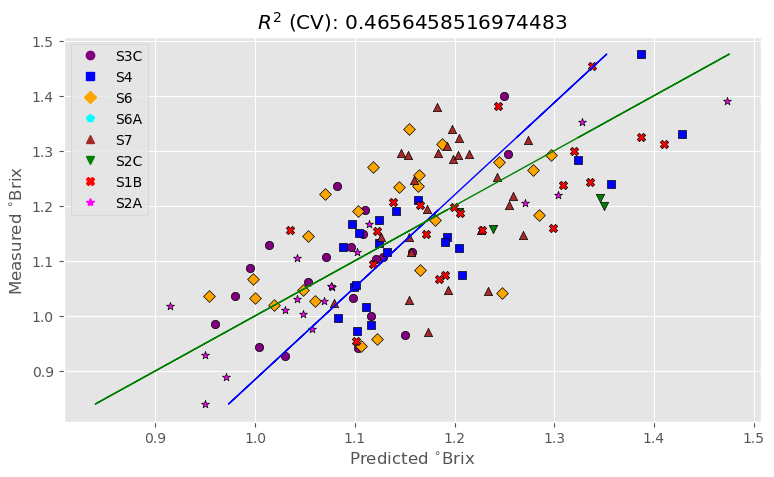

In [12]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\pn.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_pn,                         
                             ncomp, labels_pn, file_name_sla)

## sla
 

In [13]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_sla, y_sla, 25)


Optimised number of PLS components:  18
Wavelengths to be kept  29
Optimised MSEP  0.16769872044808753



[0.87538577 0.86429819 0.41080016 0.59804468 0.62287084 0.68151024
 0.70639445 0.61630828 0.92226556 0.56975511 0.48775352 0.8825915
 0.73095343 0.57954587 0.79739149 0.57215605 0.55927007 0.5610934
 0.64633903 0.97493689 0.92733294 1.16795156 1.04467558 0.9351455
 0.73462375 0.81353767 0.87536338 0.75016162 0.95928885 0.67088906
 1.06481322 0.93635947 0.74369571 0.77948796 0.91140133 0.76457076
 0.80989331 0.80610364 0.69466502 0.6700678  0.82056744 0.82764496
 0.80979014 1.01602922 0.81096879 0.51580354 0.55654604 0.59079561
 0.893731   0.27128087 1.03871169 0.6537974  0.92590812 0.88877396
 1.07318623 0.54983809 0.82913879 0.83852799 1.09235576 0.95093083
 0.61548542 1.03736869 1.13539159 1.05876669 1.25575032 0.91887716
 0.96952338 0.88036003 0.90006884 0.98670144 0.74929471 0.86024324
 0.89092284 0.93637709 1.15715274 0.81316106 1.02136941 1.0430958
 1.03028895 0.8417013  0.84143358 0.81391194 0.24458791 0.33401793
 0.39398636 0.6104456  0.75372858 0.59686573 0.59386244 0.34998288

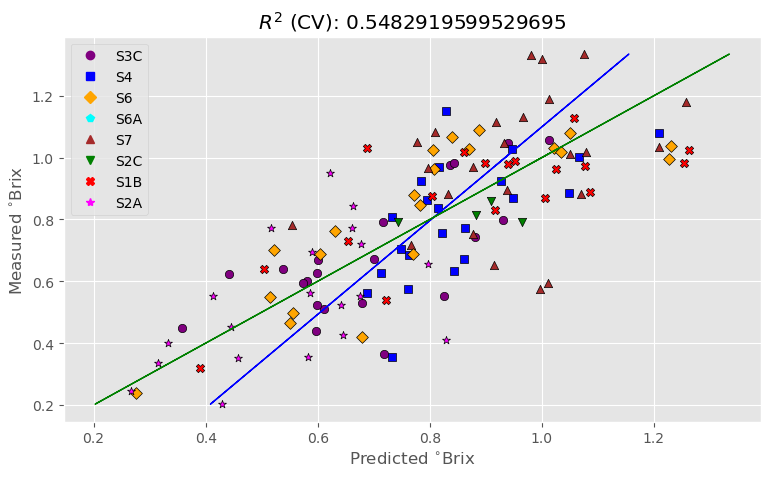

In [14]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\sla.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_sla,                         
                             ncomp, labels_sla, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## d13c

In [15]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_d13c, y_d13c, 20)


Optimised number of PLS components:  7
Wavelengths to be kept  21
Optimised MSEP  0.6753917311256867



[-28.51926925 -28.83917426 -29.18239135 -28.69427261 -28.79494215
 -28.25806956 -28.58017143 -28.41730345 -28.13161328 -28.38111803
 -28.40390238 -28.86144797 -28.48748335 -28.48916618 -28.442007
 -29.1915286  -28.72923381 -28.46494719 -28.50077111 -28.18132261
 -28.42085867 -28.60957489 -28.66407727 -28.49181715 -28.36763721
 -28.82212529 -28.77467538 -28.34977928 -27.96867036 -28.4753108
 -28.07054605 -28.60553975 -28.79108736 -27.72077944 -28.72341454
 -28.70983207 -28.74794377 -28.70988038 -29.00690312 -28.72814809
 -28.78661861 -28.10563756 -28.09823667 -27.9768239  -28.80753827
 -28.96420918 -28.62678696 -28.80443852 -29.36302116 -28.15320357
 -28.23796768 -28.29569977 -28.35891823 -28.32389201 -28.53452902
 -28.13958734 -28.58438944 -28.3586984  -28.28015585 -28.39410015
 -28.40391952 -28.49879729 -28.60929659 -28.49715933 -29.10164046
 -28.48732493 -28.32975922 -28.38687158 -27.931039   -28.67137995
 -28.40224132 -27.84620349 -28.25218894 -28.01077663 -28.15062085
 -27.99723079

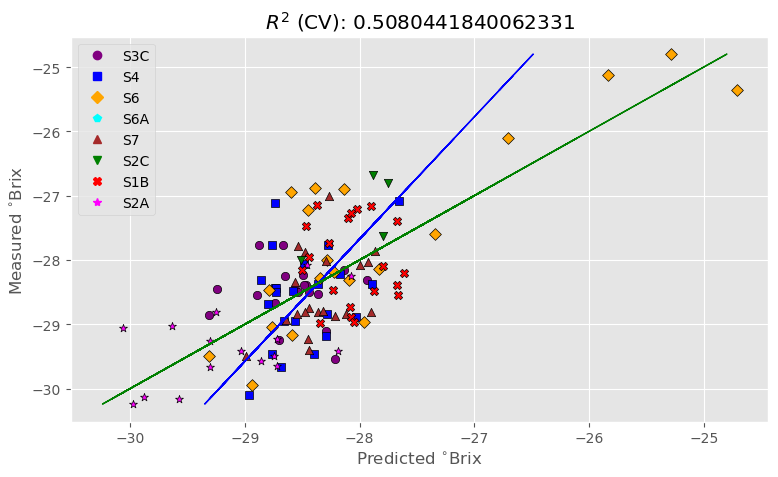

In [16]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\d13c.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_d13c,                         
                             ncomp, labels_d13c, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# d15n

In [17]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_d15n, y_d15n, 25)


Optimised number of PLS components:  22
Wavelengths to be kept  40
Optimised MSEP  1.384105644310429



[-1.55729092 -4.81964818 -1.23505318 -2.65041055 -1.41392268 -3.23671089
 -2.75725116 -2.62812277 -3.47860192 -2.63998586 -0.77512299 -1.74950012
 -1.71732876 -2.903118   -2.53442933 -2.52855282 -3.00452149 -2.54394907
 -2.46895527 -1.56240773 -1.40904516 -2.23494481 -1.70768364 -3.17753258
 -3.39945944 -2.94519184 -1.77426638 -3.41348155  0.61629026 -4.44609814
 -2.84931589 -1.99418797 -4.91445414 -2.89075276 -2.60990803 -3.6106358
 -3.92745899 -3.08360805 -0.84694404 -1.96427121 -2.54058367 -2.5145812
 -2.75296575  0.0139229   1.56067827 -1.43614993  1.44937947 -3.55274197
 -1.12017138 -0.70227052 -3.77896575  2.52859548 -3.18289992 -0.56476028
 -1.68345298 -1.52367462 -1.32232488 -1.19614244 -1.17269902 -2.06448215
 -1.10586695 -0.84869559 -0.8406514  -0.41420245  0.78171551 -1.05296806
 -1.39420169 -1.94758041  0.21903097 -0.51726626  0.560403    0.53974835
  0.77023305  1.43494878 -0.74576904  0.57001222  0.0551472   0.56213162
  1.45584503  0.84358998 -1.85431487 -0.23569503 -2.5

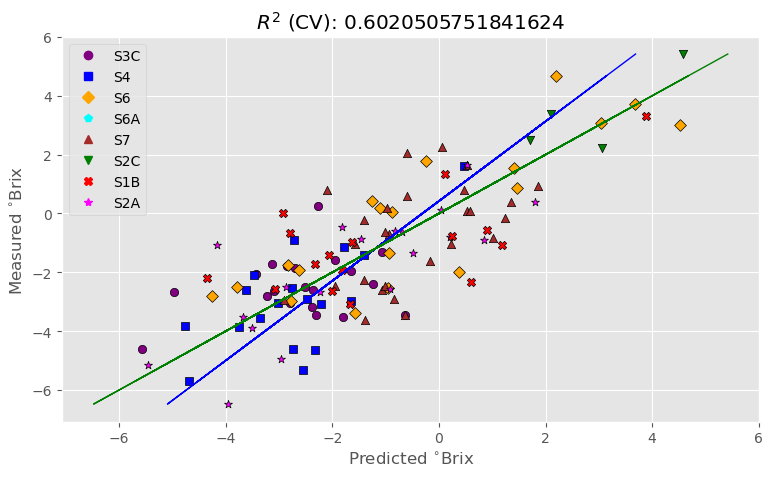

In [18]:

file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\d15n.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_d15n,                         
                             ncomp, labels_d15n, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## ldmc

In [19]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_ldmc, y_ldmc, 20)



Optimised number of PLS components:  14
Wavelengths to be kept  47
Optimised MSEP  0.07035833399114683



[2.65940759 2.72066853 2.77307125 2.67220207 2.58866144 2.65869103
 2.66652923 2.60829291 2.59653306 2.5943508  2.59001329 2.57631925
 2.66578685 2.60140721 2.66392884 2.64650554 2.68893293 2.66799992
 2.65515016 2.5866579  2.5640048  2.64596649 2.67304591 2.68768073
 2.5941501  2.65826658 2.6868602  2.4703662  2.62294896 2.70318005
 2.66254853 2.32189087 2.63555414 2.68345809 2.65118619 2.62130156
 2.69919417 2.68639263 2.52331163 2.58036686 2.55603801 2.64222826
 2.6578455  2.60842232 2.5302975  2.65565533 2.65824664 2.60824294
 2.59337586 2.58105746 2.56718772 2.66606837 2.58187136 2.58054873
 2.57291449 2.68544283 2.56315333 2.55450527 2.58914774 2.50291185
 2.51886488 2.53199907 2.52997111 2.5818483  2.57372895 2.50485436
 2.49680164 2.53967938 2.55420491 2.53305265 2.47280256 2.51366815
 2.51479547 2.51961265 2.51212022 2.58778217 2.5427297  2.53448577
 2.46439327 2.68189277 2.90862773 2.61233126 2.72989489 2.72880564
 2.67071454 2.74163568 2.66523229 2.69550489 2.76434901 2.8806

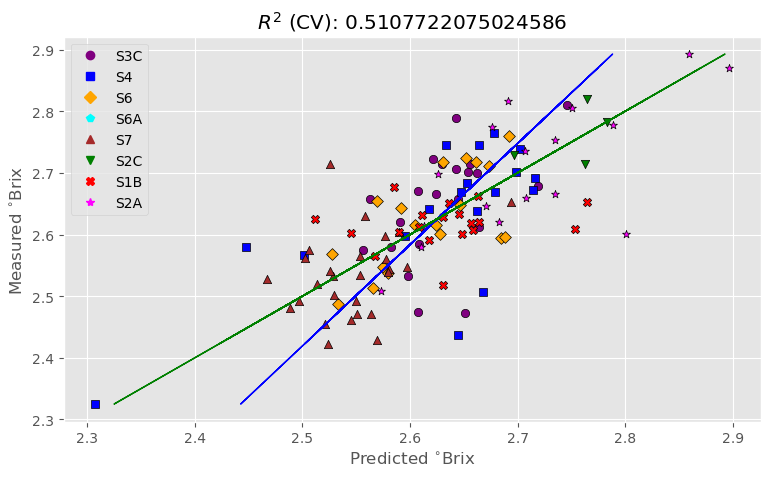

In [20]:
file_name_sla = r'D:\wenqu\2024_data\SVC\update1\trait\ldmc.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_ldmc,                         
                             ncomp, labels_ldmc, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [20]:
import pandas as pd

df1 = pd.read_csv(r"D:\wenqu\2024_data\PFT\M.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"D:\wenqu\2024_data\PFT\spectral\M.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
